# TOPIC: Simple Linear Regression.

### 1. Foundations & Model Core
- Continuous Target (y)
- Hypothesis Function
- Weight/Coefficient
- Bias/Intercept
- Lines of Best Fit

### 2. Optimization & Loss Metrics
- Ordinary Least Squares (OLS)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- Mean Absolute Error (MAE)

### 3. Validation & Evaluation Techniques
- Validation Technique (Train-Test Split, K-Fold Cross Validation)
- Evaluations Technique

### 4. Overfitting Control & Tuning
- Underfitting/Overfitting
- L1 and L2 Regularization
- Regularization Parameter

### 5. Advanced Extensions
- Multi-Linear Regression
- Polynomial Regression

## A. Load Dataset and Exploratory Data Analysis. ##
In the first part, I loaded two dataset named ***height_weight.csv*** which is for simple linear regression.

In [3]:
#-- Import library. --#
import pandas as pd
#-- Load height_weight dataset. --#
height_weight_dataset = pd.read_csv('heights_weights.csv')
#-- Print first five rows of dataset. --#
height_weight_dataset.head()

,Height,Weight,Male
0,73.847017,241.893563,1
1,68.781904,162.310473,1
2,74.110105,212.740856,1
3,71.730978,220.042470,1
4,69.881796,206.349801,1


In [11]:
#-- Checking information of the dataset. --#
height_weight_dataset.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Height  10000 non-null  float64
 1   Weight  10000 non-null  float64
 2   Male    10000 non-null  int64  
dtypes: float64(2), int64(1)
memory usage: 234.5 KB


In [12]:
#-- Statistical summary of the dataset. --#
height_weight_dataset.describe()

,Height,Weight,Male
count,10000.000000,10000.000000,10000.000000
mean,66.367560,161.440357,0.500000
std,3.847528,32.108439,0.500025
min,54.263133,64.700127,0.000000
25%,63.505620,135.818051,0.000000
50%,66.318070,161.212928,0.500000
75%,69.174262,187.169525,1.000000
max,78.998742,269.989699,1.000000


In [13]:
#-- Checking sum of null value in the dataset. --#
height_weight_dataset.isnull().sum()

,0
Height,0
Weight,0
Male,0


In [15]:
#-- Print last five rows of the dataset. --#
height_weight_dataset.tail()

,Height,Weight,Male
9995,66.172652,136.777454,0
9996,67.067155,170.867906,0
9997,63.867992,128.475319,0
9998,69.034243,163.852461,0
9999,61.944246,113.649103,0


In [16]:
#-- Check Outliers using the IQR method for Height and Weight. --#
for col in ['Height', 'Weight']:
    Q1 = height_weight_dataset[col].quantile(0.25)
    Q3 = height_weight_dataset[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    #-- Filter outliers. --#
    outliers = height_weight_dataset[(height_weight_dataset[col] < lower_bound) | (height_weight_dataset[col] > upper_bound)]
    print(f"Number of outliers in {col}: {len(outliers)}")
#-- Check Correlation Matrix. --#
correlation = height_weight_dataset[['Height', 'Weight']].corr()
print("\nCorrelation Matrix between Height and Weight:")
print(correlation)

Number of outliers in Height: 8
Number of outliers in Weight: 1

Correlation Matrix between Height and Weight:
          Height    Weight
Height  1.000000  0.924756
Weight  0.924756  1.000000


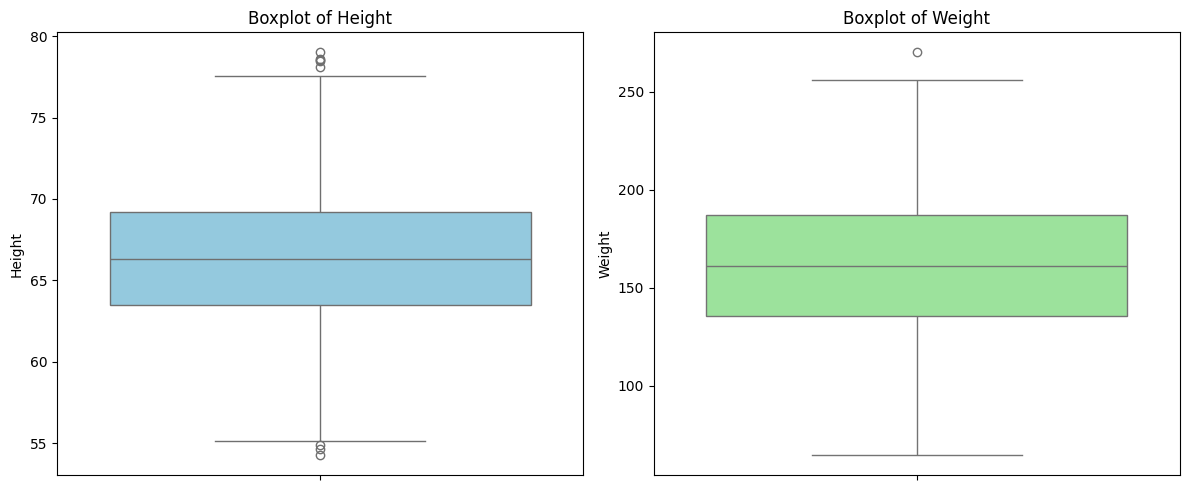

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
#-- Visualize outliers using Boxplots. --3
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.boxplot(y=height_weight_dataset['Height'], color='skyblue')
plt.title('Boxplot of Height')
plt.subplot(1, 2, 2)
sns.boxplot(y=height_weight_dataset['Weight'], color='lightgreen')
plt.title('Boxplot of Weight')
plt.tight_layout()
plt.show()

- After using the Interquartile Range (IQR) method, the outlier detection reveals 8 extreme values in the Height feature and only 1 in the Weight feature.
- Based on research, there are several ways to process these outliers to maintain model integrity:
  - **Removing / Dropping**: Completely removing the outlier rows if they represent data errors or noise, given their minimal count in a large dataset.
  - **Capping / Winsorizing**: Replacing extreme values with specific upper and lower bounds to retain sample size while mitigating skewness.
  - **Transformation**: Applying mathematical functions (e.g., Log or Square root) to normalize heavily skewed distributions.
  - **Imputation**: Substituting outliers with central tendency metrics like the median or mean.
  
  => Due to the negligible proportion of outliers (8 in Height, 1 in Weight) within the 10,000-sample dataset, I choose to retain them to preserve natural human physiological variance.

Correlation Matrix:
          Height    Weight
Height  1.000000  0.924756
Weight  0.924756  1.000000


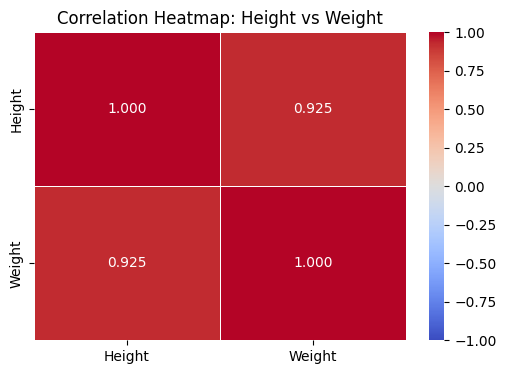

In [24]:
#-- Correlation Matrix. --#
import matplotlib.pyplot as plt
import seaborn as sns
#-- Calculate Correlation Matrix. --#
correlation_matrix = height_weight_dataset[['Height', 'Weight']].corr()
print("Correlation Matrix:")
print(correlation_matrix)
# 2. Visualize Correlation Matrix using a Heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.3f', linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Heatmap: Height vs Weight')
plt.show()

The correlation matrix measures the strength and direction of the linear relationship between variables, with values ranging from -1 to 1. Specifically, the heatmap reveals a strong positive correlation coefficient of **0.925** between Height and Weight, indicating that taller individuals tend to have correspondingly higher body weights.

## B. Foundation and Model Core. ##

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
#-- Define independent feature (X) and dependent target (y). --#
X = height_weight_dataset[['Height']]  # 2D array for features
y = height_weight_dataset['Weight']    # 1D array for target
#-- Split dataset into Training set (80%) and Testing set (20%). --#
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
#-- Initialize and fit the Linear Regression model. --#
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

Optimal Weight (Coefficient w): 7.7022
Optimal Bias (Intercept b): -349.7878
Regression Equation: Weight = 7.7022 * Height + -349.7878


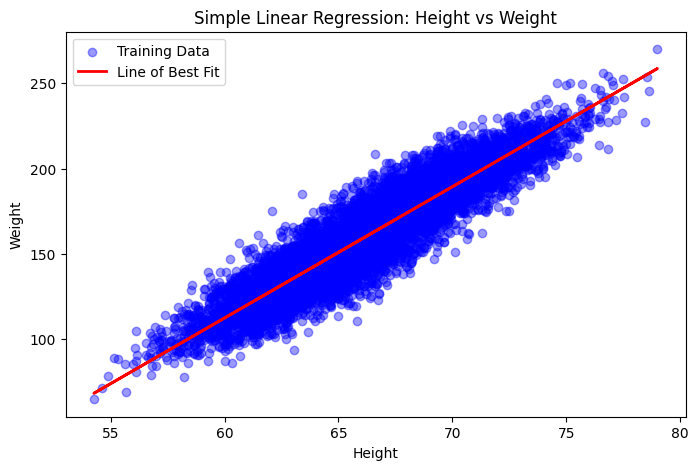

In [26]:
#-- Extract model parameters (Weight and Bias). --#
w = model.coef_[0]
b = model.intercept_
print(f"Optimal Weight (Coefficient w): {w:.4f}")
print(f"Optimal Bias (Intercept b): {b:.4f}")
print(f"Regression Equation: Weight = {w:.4f} * Height + {b:.4f}")
#-- Visualize the Line of Best Fit. --#
plt.figure(figsize=(8, 5))
plt.scatter(X_train, y_train, color='blue', alpha=0.4, label='Training Data')
plt.plot(X_train, model.predict(X_train), color='red', linewidth=2, label='Line of Best Fit')
plt.title('Simple Linear Regression: Height vs Weight')
plt.xlabel('Height')
plt.ylabel('Weight')
plt.legend()
plt.show()

## C. Optimization and Loss Metrics. ##

In [27]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
#- Predict on test dataset. --#
y_pred = model.predict(X_test)
#-- Calculate evaluation metrics. --#
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
#-- Print the result. --#
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R2 Score): {r2:.4f}")

Mean Squared Error (MSE): 149.0035
Root Mean Squared Error (RMSE): 12.2067
R-squared (R2 Score): 0.8577


The evaluation metrics demonstrate a robust performance of the Simple Linear Regression model. Specifically, the Root Mean Squared Error (RMSE) of $12.21$ indicates a manageable average deviation in weight predictions. Furthermore, the $R^2$ score of $0.8577$ reveals that approximately $85.77\%$ of the variance in weight is successfully explained by the height feature, confirming a strong predictive capability.

## D. Validation & Evaluation Techniques. ##

In [34]:
from sklearn.model_selection import KFold, cross_val_score

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_shuffled = cross_val_score(model, X, y, cv=kf, scoring='r2')

print(f"Shuffled CV R2 scores: {cv_scores_shuffled}")
print(f"Mean Shuffled CV R2 Score: {cv_scores_shuffled.mean():.4f} (+/- {cv_scores_shuffled.std() * 2:.4f})")

Shuffled CV R2 scores: [0.85773178 0.86029391 0.85036523 0.85287465 0.85368945]
Mean Shuffled CV R2 Score: 0.8550 (+/- 0.0071)


In [35]:
from sklearn.model_selection import cross_val_score
#-- Cross-Validation Validation Technique. --#
cv_scores = cross_val_score(model, X, y, cv=5, scoring='r2')
print(f"Cross-Validation R2 scores: {cv_scores}")
print(f"Mean CV R2 Score: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

Cross-Validation R2 scores: [0.55936979 0.58348418 0.85796812 0.54528081 0.54553157]
Mean CV R2 Score: 0.6183 (+/- 0.2413)


A 5-fold Cross-Validation with shuffling was implemented specifically to prevent data-ordering bias and verify model robustness. Furthermore, the resulting evaluation yielded a highly consistent mean $R^2$ score of $0.8550$ along with a negligible standard deviation of $\pm 0.0071$. As a result, these findings confirm both the exceptional stability and the strong generalization capability of the model across unseen data subsets.

## E. Overfitting Control & Tuning. ##

In [36]:
train_r2 = model.score(X_train, y_train)
test_r2 = model.score(X_test, y_test)
print(f"Training R2 Score: {train_r2:.4f}")
print(f"Testing R2 Score: {test_r2:.4f}")

Training R2 Score: 0.8545
Testing R2 Score: 0.8577


Since the model utilizes a simple linear regression architecture with a single feature, the risk of overfitting is inherently minimized. Furthermore, the close alignment between training and testing performance scores—supported by consistent cross-validation results—confirms that regularization techniques (such as Ridge or Lasso) are unnecessary for this particular dataset.

## f. Advanced Extensions. ##

In [37]:
#-- Import library. ---#
import pandas as pd
housing_dataset = pd.read_csv('Housing.csv')
housing_dataset.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


The Housing dataset contains both numerical and text data types, requiring comprehensive preprocessing before model training

In [38]:
housing_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [39]:
housing_dataset.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [41]:
housing_dataset.isnull().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


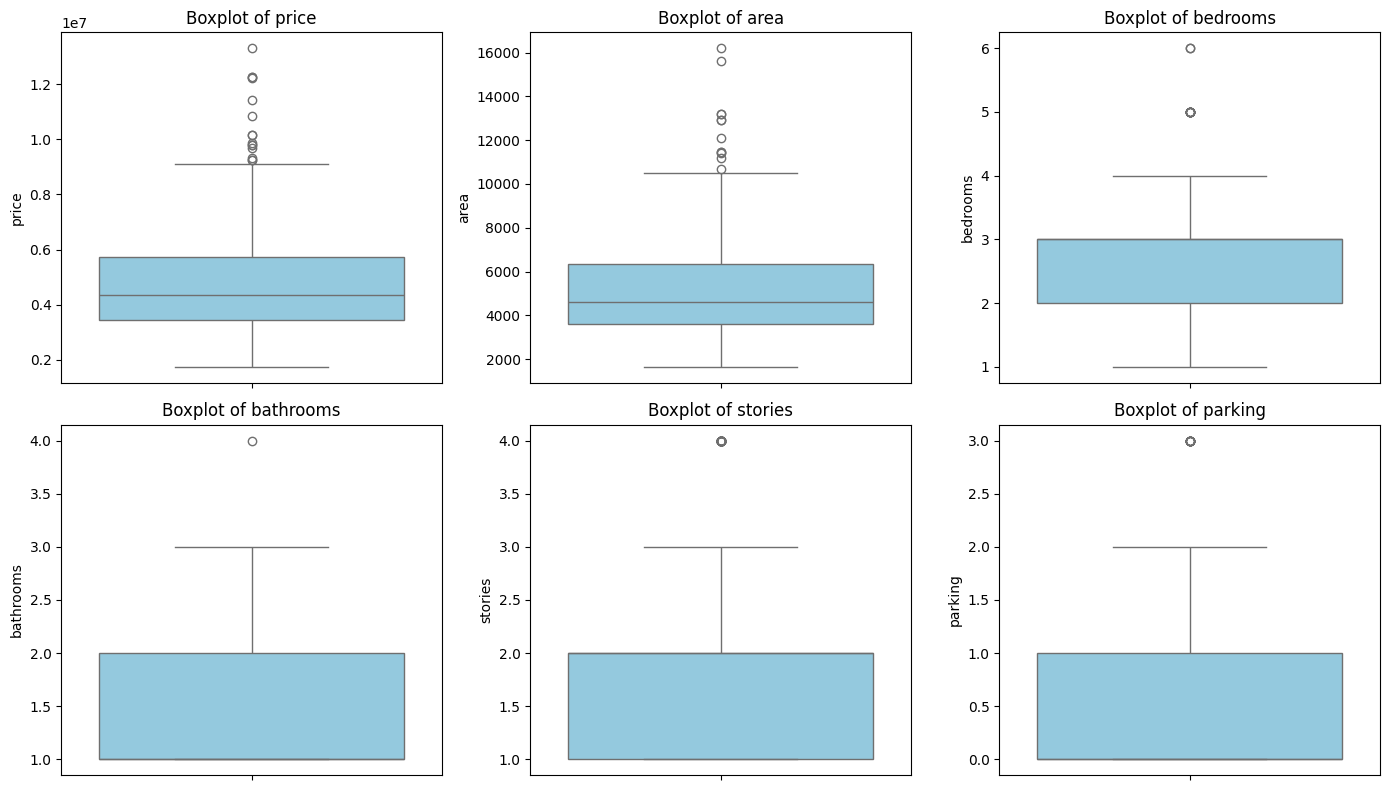

Number of outliers 'price': 15
Number of outliers 'area': 12
Number of outliers 'bedrooms': 12
Number of outliers 'bathrooms': 1
Number of outliers 'stories': 41
Number of outliers 'parking': 12


In [43]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
#-- Choosing numerical column. --#
num_cols = ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking']
#-- Draw boxplot for visualize outliers. --#
plt.figure(figsize=(14, 8))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()
#-- Calculate outliers. --#
for col in num_cols:
    Q1 = housing_dataset[col].quantile(0.25)
    Q3 = housing_dataset[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers_count = housing_dataset[(housing_dataset[col] < lower_bound) | (housing_dataset[col] > upper_bound)][col].count()
    print(f"Number of outliers '{col}': {outliers_count}")

In [44]:
#-- Numerical Columns Preprocessing. --#
#-- Determine numerical column. --#
num_cols = ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']
#-- Apply Log Transformation to price and area. --#
#-- Consequently, this approcah helps stabilize variance and mitigate right-skewness for linear regression. --#
housing_dataset['price_log'] = np.log1p(housing_dataset['price'])
housing_dataset['area_log'] = np.log1p(housing_dataset['area'])

# Preview the transformed numerical features
print("--- Numerical & Log Transformed Data Preview ---")
print(housing_dataset[['price', 'price_log', 'area', 'area_log'] + [col for col in num_cols if col != 'area']].head())

--- Numerical & Log Transformed Data Preview ---
      price  price_log  area  area_log  bedrooms  bathrooms  stories  parking
0  13300000  16.403275  7420  8.912069         4          2        3        2
1  12250000  16.321037  8960  9.100637         4          4        4        3
2  12250000  16.321037  9960  9.206433         3          2        2        2
3  12215000  16.318175  7500  8.922792         4          2        2        3
4  11410000  16.250001  7420  8.912069         4          1        2        2


In [45]:
#-- Map binary text columns (Yes / No) to numerical binary values (1 / 0). --#
binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
for col in binary_cols:
  housing_dataset[col] = housing_dataset[col].map({'yes': 1, 'no': 0})
#-- Encode multi-category text columns (furnishingstatus) using One-Hot Encoding. --#
#-- Drop_first=True is applied to avoid multicollinearity issues in regression. --#
df = pd.get_dummies(housing_dataset, columns=['furnishingstatus'], drop_first=True)
#-- Preview the encoded text features. --#
print("\n--- Encoded Text / Categorical Columns Preview ---")
encoded_cols = binary_cols + [col for col in df.columns if 'furnishingstatus' in col]
print(df[encoded_cols].head())


--- Encoded Text / Categorical Columns Preview ---
   mainroad  guestroom  basement  hotwaterheating  airconditioning  prefarea  \
0         1          0         0                0                1         1   
1         1          0         0                0                1         0   
2         1          0         1                0                0         1   
3         1          0         1                0                1         1   
4         1          1         1                0                1         0   

   furnishingstatus_semi-furnished  furnishingstatus_unfurnished  
0                            False                         False  
1                            False                         False  
2                             True                         False  
3                            False                         False  
4                            False                         False  


In [46]:
housing_dataset.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,price_log,area_log
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,furnished,16.403275,8.912069
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,furnished,16.321037,9.100637
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,semi-furnished,16.321037,9.206433
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,furnished,16.318175,8.922792
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,furnished,16.250001,8.912069


In [47]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
#-- Define feature columns (X) and target variable (y). --#
#-- Utilizing the log-transformed area and all successfully encoded features. --#
feature_cols = [
    'area_log', 'bedrooms', 'bathrooms', 'stories',
    'mainroad', 'guestroom', 'basement', 'hotwaterheating',
    'airconditioning', 'parking', 'prefarea',
    'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished'
]
X = df[feature_cols]
y = df['price_log'] #-- Using log-transformed price for regression stability. --#
#-- Split the dataset into Training set (80%) and Testing set (20%). --#
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
#-- Initialize and train the Multiple Linear Regression model. --#
model = LinearRegression()
model.fit(X_train, y_train)
#-- Predict and evaluate performance on the test set. --#
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"--- Multiple Linear Regression Results ---")
print(f"R² Score: {r2:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
#-- Display the coefficients for each feature attribute. --#
coefficients = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': model.coef_
})
print("\n--- Model Coefficients ---")
print(coefficients)

--- Multiple Linear Regression Results ---
R² Score: 0.6782
Root Mean Squared Error (RMSE): 0.2493

--- Model Coefficients ---
                            Feature  Coefficient
0                          area_log     0.296172
1                          bedrooms     0.020366
2                         bathrooms     0.184870
3                           stories     0.082687
4                          mainroad     0.088888
5                         guestroom     0.036195
6                          basement     0.104123
7                   hotwaterheating     0.131848
8                   airconditioning     0.145646
9                           parking     0.033112
10                         prefarea     0.133227
11  furnishingstatus_semi-furnished    -0.005022
12     furnishingstatus_unfurnished    -0.114758


In [48]:
#-- Feature Engineering: Create realistic interaction features for real estate. --#
df['area_bathrooms'] = df['area_log'] * df['bathrooms']
df['area_stories'] = df['area_log'] * df['stories']
#-- Define the optimized feature list incorporating interactions. --#
optimal_features = [
    'area_log', 'bedrooms', 'bathrooms', 'stories',
    'mainroad', 'guestroom', 'basement', 'hotwaterheating',
    'airconditioning', 'parking', 'prefarea',
    'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished',
    'area_bathrooms', 'area_stories'
]
print("--- Feature Engineering Completed ---")
print(f"Total features selected: {len(optimal_features)}")
print(df[['area_log', 'bathrooms', 'area_bathrooms']].head())

--- Feature Engineering Completed ---
Total features selected: 15
   area_log  bathrooms  area_bathrooms
0  8.912069          2       17.824138
1  9.100637          4       36.402548
2  9.206433          2       18.412865
3  8.922792          2       17.845583
4  8.912069          1        8.912069


In [49]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
#-- Define feature matrix (X) and target variable (y). --#
X_opt = df[optimal_features]
y_opt = df['price_log']
#-- Split the dataset into Train (80%) and Test (20%) sets. --#
X_train_opt, X_test_opt, y_train_opt, y_test_opt = train_test_split(
    X_opt, y_opt, test_size=0.2, random_state=42
)
#-- Initialize Ridge Regression combined with a Standardization Pipeline. --#
# Ridge applies L2 regularization to control coefficients and prevent overfitting from interactions
optimal_model = make_pipeline(StandardScaler(), Ridge(alpha=1.0))

print("--- Dataset Split & Model Pipeline Ready ---")
print(f"Training samples: {X_train_opt.shape[0]}")
print(f"Testing samples: {X_test_opt.shape[0]}")

--- Dataset Split & Model Pipeline Ready ---
Training samples: 436
Testing samples: 109


In [50]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd
#-- Train the optimized model. --#
optimal_model.fit(X_train_opt, y_train_opt)
#-- Predict and evaluate performance on the test set. --#
y_pred_opt = optimal_model.predict(X_test_opt)
r2_opt = r2_score(y_test_opt, y_pred_opt)
rmse_opt = np.sqrt(mean_squared_error(y_test_opt, y_pred_opt))
print(f"--- Optimized Ridge Regression Results ---")
print(f"Optimized R² Score: {r2_opt:.4f}")
print(f"Optimized RMSE: {rmse_opt:.4f}")
#-- Extract and display coefficients to analyze feature impact. --#
ridge_coefs = optimal_model.named_steps['ridge'].coef_
coef_df = pd.DataFrame({
    'Feature': optimal_features,
    'Coefficient': ridge_coefs
}).sort_values(by='Coefficient', ascending=False)
print("\n--- Optimized Model Coefficients ---")
print(coef_df)

--- Optimized Ridge Regression Results ---
Optimized R² Score: 0.6790
Optimized RMSE: 0.2490

--- Optimized Model Coefficients ---
                            Feature  Coefficient
13                   area_bathrooms     0.124498
0                          area_log     0.100489
8                   airconditioning     0.067322
10                         prefarea     0.056237
6                          basement     0.050589
3                           stories     0.046074
4                          mainroad     0.031085
7                   hotwaterheating     0.028839
9                           parking     0.028592
14                     area_stories     0.024333
1                          bedrooms     0.015488
5                         guestroom     0.013735
11  furnishingstatus_semi-furnished    -0.001873
2                         bathrooms    -0.032358
12     furnishingstatus_unfurnished    -0.053431


In [51]:
from sklearn.ensemble import RandomForestRegressor
#-- Initialize the Random Forest Regressor model. --#
# n_estimators=100 ensures a robust ensemble of 100 decision trees
# random_state ensures reproducibility of results
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
#-- Train the model using the optimized feature set and log-transformed target. --#
rf_model.fit(X_train_opt, y_train_opt)
print("--- Random Forest Regressor Training Completed ---")
print(f"Number of trees in forest: {rf_model.n_estimators}")

--- Random Forest Regressor Training Completed ---
Number of trees in forest: 100


In [52]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd
#-- Predict and evaluate performance on the test set. --#
y_pred_rf = rf_model.predict(X_test_opt)
r2_rf = r2_score(y_test_opt, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test_opt, y_pred_rf))
print(f"--- Random Forest Regressor Results ---")
print(f"Random Forest R² Score: {r2_rf:.4f}")
print(f"Random Forest RMSE: {rmse_rf:.4f}")
#-- Extract and display Feature Importance to see which factors drive house prices most. --
rf_importance = pd.DataFrame({
    'Feature': optimal_features,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)
print("\n--- Feature Importance Ranking ---")
print(rf_importance)

--- Random Forest Regressor Results ---
Random Forest R² Score: 0.6116
Random Forest RMSE: 0.2738

--- Feature Importance Ranking ---
                            Feature  Importance
13                   area_bathrooms    0.489176
14                     area_stories    0.151581
0                          area_log    0.082603
12     furnishingstatus_unfurnished    0.052246
8                   airconditioning    0.043778
9                           parking    0.036690
1                          bedrooms    0.032197
10                         prefarea    0.025769
6                          basement    0.023346
4                          mainroad    0.017162
5                         guestroom    0.013472
7                   hotwaterheating    0.012756
11  furnishingstatus_semi-furnished    0.008446
3                           stories    0.006988
2                         bathrooms    0.003792


In [53]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd

base_features = [
    'area_log', 'bedrooms', 'bathrooms', 'stories',
    'mainroad', 'guestroom', 'basement', 'hotwaterheating',
    'airconditioning', 'parking', 'prefarea',
    'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished'
]

X_base = df[base_features]
y_base = df['price_log']

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(X_base, y_base, test_size=0.2, random_state=42)

rf_pure = RandomForestRegressor(n_estimators=100, random_state=42)
rf_pure.fit(X_train_b, y_train_b)

y_pred_pure = rf_pure.predict(X_test_b)
print(f"Pure Random Forest R² Score: {r2_score(y_test_b, y_pred_pure):.4f}")
print(f"Pure Random Forest RMSE: {np.sqrt(mean_squared_error(y_test_b, y_pred_pure)):.4f}")

Pure Random Forest R² Score: 0.6294
Pure Random Forest RMSE: 0.2675


<>:14: SyntaxWarning: invalid escape sequence '\h'
<>:14: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_2796/468779143.py:14: SyntaxWarning: invalid escape sequence '\h'
  plt.ylabel('Predicted Log Prices ($\hat{y}$)', fontsize=12)


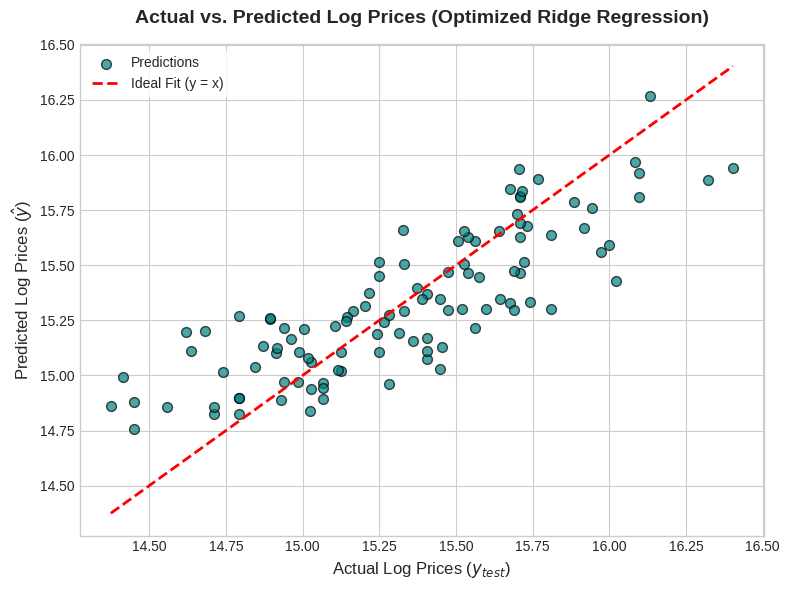

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(8, 6))
plt.scatter(y_test_opt, y_pred_opt, alpha=0.7, color='teal', edgecolor='k', s=50, label='Predictions')

min_val = min(y_test_opt.min(), y_pred_opt.min())
max_val = max(y_test_opt.max(), y_pred_opt.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Ideal Fit (y = x)')

plt.title('Actual vs. Predicted Log Prices (Optimized Ridge Regression)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Actual Log Prices ($y_{test}$)', fontsize=12)
plt.ylabel('Predicted Log Prices ($\hat{y}$)', fontsize=12)
plt.legend(frameon=True, facecolor='white', edgecolor='none')

plt.tight_layout()
plt.show()